# Embedding-Matrix Geometry Analysis — Llama-3-8B vs SinLlama

This notebook analyses and **compares the input token-embedding matrices**
(`model.model.embed_tokens.weight`) of two checkpoints:

| Key | Path | Vocab size | Note |
|-----|------|-----------:|------|
| `Llama-3-8B` | `models/llama-3-8b` | 128,256 | original Meta base model |
| `SinLlama`   | `models/SinLlama_merged_bf16` | 139,336 | Sinhala continual-pretraining; vocabulary **extended by 11,080 new tokens** (ids ≥ 128256) |

Because both models share the Llama-3 architecture, ids `0 … 128255` refer to
the *same* original tokens in both — so we can directly compare how continual
pretraining moved the original embeddings, and study the geometry of the
**newly-added Sinhala token embeddings** that only exist in SinLlama.

We only need the embedding tensor (~1 GB in bf16), so we load **just that one
tensor** out of shard 1 with `safetensors` rather than instantiating the full
8-B-parameter model.

The notebook follows the checklist in `weights_analysis/todo.txt`:
load & inspect → basic stats → norms → cosine similarity → nearest neighbours →
PCA / UMAP / t-SNE → clustering → SVD spectrum → anisotropy → token-category
analysis → distance distribution → research-question summary.

## 0. Setup — imports, configuration, helpers

In [1]:
# --- Core numerical / plotting stack -------------------------------------
import os, re, json, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- ML utilities ---------------------------------------------------------
import torch
from safetensors import safe_open
from transformers import AutoTokenizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import linkage, dendrogram
import umap  # umap-learn

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

# --- Reproducibility & global config -------------------------------------
SEED = 42
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

# Paths to the two checkpoints (edit if your layout differs).
MODEL_PATHS = {
    "Llama-3-8B": "/ml/SinLlama_CPT/models/llama-3-8b",
    "SinLlama":   "/ml/SinLlama_CPT/models/SinLlama_merged_bf16",
}
ORIG_VOCAB = 128256          # size of the base Llama-3 vocabulary
FIG_DIR = "/ml/SinLlama_CPT/weights_analysis/figures"
os.makedirs(FIG_DIR, exist_ok=True)

# Subset sizes for the expensive projection / clustering steps.
SUBSET_SIZE   = 8000    # PCA scatter, UMAP, KMeans
TSNE_SIZE     = 3000    # t-SNE (O(n^2), keep small)
HIER_SIZE     = 1200    # hierarchical clustering / dendrogram
PAIRWISE_N    = 5000    # random sample for pairwise-similarity histogram
HUB_N         = 5000    # sample for hubness (k-occurrence) analysis

def savefig(name):
    "Save the current figure into FIG_DIR and also display it inline."
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, name), bbox_inches="tight")
    plt.show()

print("Setup complete. Figures will be written to:", FIG_DIR)

Setup complete. Figures will be written to: /ml/SinLlama_CPT/weights_analysis/figures


## 1. Load and inspect

We read only the `model.embed_tokens.weight` tensor from the checkpoint's
first shard, cast bf16 → float32 (numpy/sklearn cannot operate on bf16),
verify the shape, and report dtype + parameter count.

In [2]:
def _embed_shard(model_path, weight="model.embed_tokens.weight"):
    "Locate the safetensors shard that stores the embedding matrix."
    idx = os.path.join(model_path, "model.safetensors.index.json")
    if os.path.exists(idx):
        weight_map = json.load(open(idx))["weight_map"]
        return os.path.join(model_path, weight_map[weight])
    return os.path.join(model_path, "model.safetensors")  # single-file fallback

def load_embedding_matrix(model_path, weight="model.embed_tokens.weight"):
    "Load ONLY the embedding tensor (not the whole model) and return float32 numpy."
    shard = _embed_shard(model_path, weight)
    with safe_open(shard, framework="pt", device="cpu") as f:
        w = f.get_tensor(weight)          # e.g. torch.bfloat16 [vocab, hidden]
    orig_dtype = w.dtype
    return w.to(torch.float32).numpy(), orig_dtype

# Load both embedding matrices + tokenizers into a single registry dict.
MODELS = {}
for key, path in MODEL_PATHS.items():
    emb, dtype = load_embedding_matrix(path)
    tok = AutoTokenizer.from_pretrained(path)
    MODELS[key] = {"emb": emb, "dtype": dtype, "tok": tok, "path": path}
    n_params = emb.shape[0] * emb.shape[1]
    print(f"{key:12s} shape={emb.shape}  dtype(orig)={dtype}  "
          f"params={n_params:,}  base_dtype_now={emb.dtype}")

# SUMMARY accumulates scalar metrics for the final comparison table.
SUMMARY = {k: {} for k in MODELS}

Llama-3-8B   shape=(128256, 4096)  dtype(orig)=torch.bfloat16  params=525,336,576  base_dtype_now=float32
SinLlama     shape=(139336, 4096)  dtype(orig)=torch.bfloat16  params=570,720,256  base_dtype_now=float32


### 1b. Token categorisation

To interpret the geometry we tag every token id with a coarse category
(English word, sub-word fragment, punctuation, number, whitespace, special,
**Sinhala**, other-non-English). Sinhala is detected via the Unicode block
`U+0D80–U+0DFF`. We also flag which tokens are **new** in SinLlama
(id ≥ 128256). Decoding ~139k tokens takes a few seconds.

In [3]:
SIN_RE     = re.compile(r"[඀-෿]")   # Sinhala Unicode block
SPECIAL_RE = re.compile(r"^<\|.*\|>$")          # <|begin_of_text|> etc.

# Consistent colour per category for every scatter plot in the notebook.
CAT_COLORS = {
    "english_word":      "#1f77b4",
    "subword_fragment":  "#aec7e8",
    "sinhala":           "#d62728",
    "non_english_other": "#ff9896",
    "number":            "#2ca02c",
    "punctuation":       "#9467bd",
    "whitespace":        "#8c564b",
    "special":           "#7f7f7f",
    "other":             "#bcbd22",
}

def classify(i, readable, piece, special_ids):
    "Map one token to a coarse category using its decoded string."
    if i in special_ids or SPECIAL_RE.match(piece or ""):
        return "special"
    s = readable.strip()
    if s == "":
        return "whitespace"
    if SIN_RE.search(readable):
        return "sinhala"
    if not readable.isascii():
        return "non_english_other"
    leading_space = readable[:1] == " "     # word-start vs continuation piece
    if s.isdigit():
        return "number"
    if all(not c.isalnum() for c in s):
        return "punctuation"
    if s.replace("'", "").isalpha():
        return "english_word" if leading_space else "subword_fragment"
    if any(c.isdigit() for c in s):
        return "number"
    return "other"

def build_categories(entry):
    "Compute per-token category array + human-readable strings for a model."
    tok = entry["tok"]
    vocab = entry["emb"].shape[0]
    special_ids = set(tok.all_special_ids)
    pieces   = tok.convert_ids_to_tokens(list(range(vocab)))       # raw BPE pieces
    readable = [tok.decode([i]) for i in range(vocab)]             # unicode strings
    cats = np.array([classify(i, readable[i], pieces[i], special_ids)
                     for i in range(vocab)])
    return cats, np.array(readable, dtype=object)

for key, entry in MODELS.items():
    cats, readable = build_categories(entry)
    entry["cats"] = cats
    entry["readable"] = readable
    entry["is_new"] = np.arange(entry["emb"].shape[0]) >= ORIG_VOCAB
    print(f"\n=== {key} category counts ===")
    print(pd.Series(cats).value_counts().to_string())
    if entry["is_new"].any():
        print(f"new tokens (id>={ORIG_VOCAB}): {int(entry['is_new'].sum()):,}")


=== Llama-3-8B category counts ===
english_word         43044
non_english_other    30054
subword_fragment     29430
other                18316
punctuation           5516
number                1110
whitespace             530
special                256

=== SinLlama category counts ===
english_word         43044
non_english_other    30054
subword_fragment     29430
other                18316
sinhala              11080
punctuation           5516
number                1110
whitespace             530
special                256
new tokens (id>=128256): 11,080


### 1c. Unit-normalised embeddings & norms

Many analyses (cosine similarity, anisotropy) need L2-normalised vectors.
We precompute the norm of every embedding and a unit-normalised copy, guarding
against zero-vectors (some reserved special tokens are all-zero).

In [4]:
for key, entry in MODELS.items():
    emb = entry["emb"]
    norms = np.linalg.norm(emb, axis=1)          # L2 norm of every embedding
    safe = np.where(norms == 0, 1.0, norms)      # avoid divide-by-zero
    entry["norms"] = norms
    entry["unit"]  = (emb / safe[:, None]).astype(np.float32)
    n_zero = int((norms == 0).sum())
    print(f"{key:12s} norm mean={norms.mean():.3f}  std={norms.std():.3f}  "
          f"zero-vectors={n_zero}")

Llama-3-8B   norm mean=0.593  std=0.073  zero-vectors=0
SinLlama     norm mean=0.596  std=0.113  zero-vectors=0


## 2. Basic statistics

Element-wise mean / std / min / max of the raw embedding weights, plus the
distribution of per-token L2 norms. These summarise the overall scale of the
learned representations.

In [5]:
rows = []
for key, entry in MODELS.items():
    e = entry["emb"]
    rows.append({
        "model": key,
        "shape": str(e.shape),
        "mean":  e.mean(),
        "std":   e.std(),
        "min":   e.min(),
        "max":   e.max(),
        "norm_mean": entry["norms"].mean(),
        "norm_std":  entry["norms"].std(),
    })
stats_df = pd.DataFrame(rows).set_index("model")
display(stats_df.round(4))

,shape,mean,std,min,max,norm_mean,norm_std
model,,,,,,,
Llama-3-8B,"(128256, 4096)",0.0,0.0093,-0.082,0.2256,0.5926,0.0733
SinLlama,"(139336, 4096)",0.0,0.0095,-0.082,0.2256,0.5961,0.1129


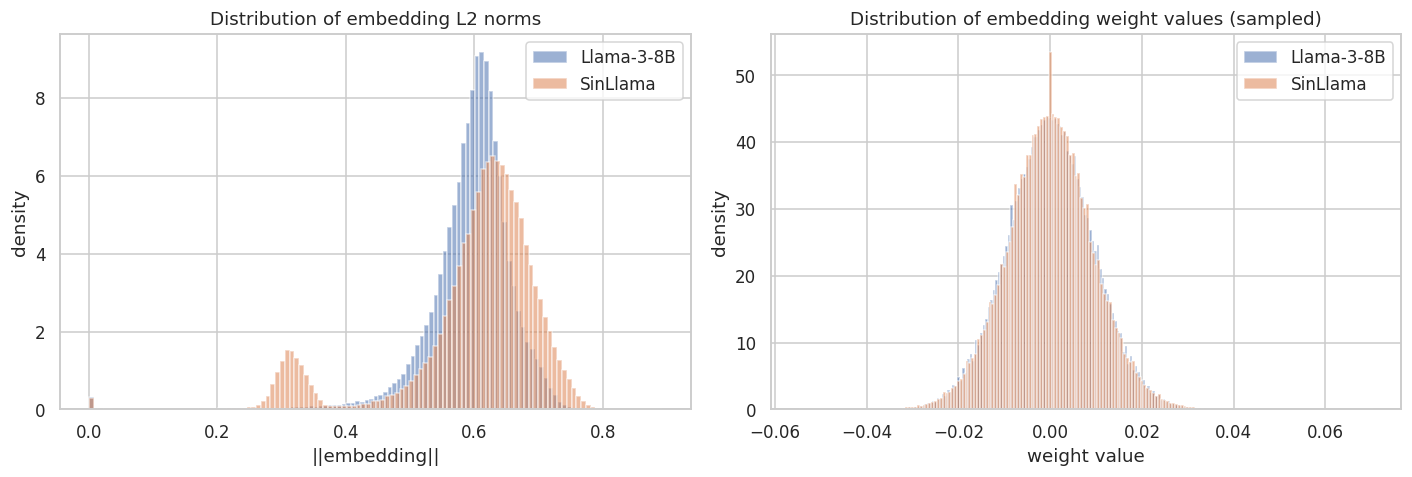

In [6]:
# Distribution of per-token L2 norms (overlaid) + a sampled value histogram.
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for key, entry in MODELS.items():
    ax[0].hist(entry["norms"], bins=120, alpha=0.55, label=key, density=True)
ax[0].set_title("Distribution of embedding L2 norms")
ax[0].set_xlabel("||embedding||"); ax[0].set_ylabel("density"); ax[0].legend()

for key, entry in MODELS.items():
    # Sample 300 random rows fully to visualise the per-element value spread.
    idx = rng.choice(entry["emb"].shape[0], size=300, replace=False)
    vals = entry["emb"][idx].ravel()
    ax[1].hist(vals, bins=200, alpha=0.55, label=key, density=True)
ax[1].set_title("Distribution of embedding weight values (sampled)")
ax[1].set_xlabel("weight value"); ax[1].set_ylabel("density"); ax[1].legend()
savefig("02_basic_distributions.png")

In [7]:
# Outlier check: tokens whose norm is >3 std from the mean norm.
for key, entry in MODELS.items():
    n = entry["norms"]
    hi = n.mean() + 3 * n.std()
    lo = n.mean() - 3 * n.std()
    out = np.where((n > hi) | (n < lo))[0]
    print(f"{key}: {len(out)} norm-outliers (>|3 sigma|). "
          f"value range=[{entry['emb'].min():.2f}, {entry['emb'].max():.2f}]")
    top = out[np.argsort(-n[out])][:8]
    print("   largest-norm outliers:",
          [(repr(entry['readable'][i]), round(float(n[i]), 2)) for i in top])

Llama-3-8B: 1821 norm-outliers (>|3 sigma|). value range=[-0.08, 0.23]
   largest-norm outliers: [("'innitus'", 0.86), ("'喔'", 0.82), ("'jejer'", 0.37), ("'\\ufeff#'", 0.37), ("'\\u3000\\u3000\\u3000\\u3000\\u3000\\u3000\\u3000\\u3000'", 0.37), ("'hledem'", 0.37), ("'ایسه'", 0.37), ("' Üniversit'", 0.37)]
SinLlama: 1026 norm-outliers (>|3 sigma|). value range=[-0.08, 0.23]
   largest-norm outliers: [("' කෙරෙනවා'", 0.26), ("' දකිනවා'", 0.26), ("' මහණෙනි'", 0.26), ("'№№'", 0.26), ("' දැක්විය'", 0.26), ("' ඔක්තෝ'", 0.26), ("'ාවේදී'", 0.26), ("' හෙයිනි'", 0.26)]


## 3. Cosine-similarity analysis

Cosine similarity between selected token pairs, and top-k nearest neighbours
for a query token, contrasting common words, rare words, punctuation, numbers
and special tokens. We also render a similarity heatmap for a small token
group.

In [8]:
def single_token_id(tok, s):
    "Return the id if `s` (optionally with a leading space) is ONE token, else None."
    for cand in (s, " " + s):
        ids = tok.encode(cand, add_special_tokens=False)
        if len(ids) == 1:
            return ids[0]
    return None

def nearest_neighbors(entry, token_id, k=10):
    "Top-k cosine neighbours of a token id within the same model."
    sims = entry["unit"] @ entry["unit"][token_id]      # [vocab] cosine sims
    order = np.argsort(-sims)
    order = order[order != token_id][:k]
    return [(int(j), entry["readable"][j], float(sims[j])) for j in order]

# Cosine similarity of a few hand-picked pairs, per model.
PAIRS = [("king", "queen"), ("cat", "dog"), ("run", "running"),
         ("good", "bad"), ("one", "two")]
for key, entry in MODELS.items():
    print(f"\n=== {key}: cosine similarity of selected pairs ===")
    for a, b in PAIRS:
        ia, ib = single_token_id(entry["tok"], a), single_token_id(entry["tok"], b)
        if ia is None or ib is None:
            print(f"  {a!r:>10} ~ {b!r:<10}  (not single tokens)"); continue
        cs = float(entry["unit"][ia] @ entry["unit"][ib])
        print(f"  {a!r:>10} ~ {b!r:<10}  cos = {cs:+.3f}")


=== Llama-3-8B: cosine similarity of selected pairs ===
      'king' ~ 'queen'     cos = +0.101
       'cat' ~ 'dog'       cos = +0.135
       'run' ~ 'running'   cos = +0.260
      'good' ~ 'bad'       cos = +0.197
       'one' ~ 'two'       cos = +0.159

=== SinLlama: cosine similarity of selected pairs ===
      'king' ~ 'queen'     cos = +0.066
       'cat' ~ 'dog'       cos = +0.115
       'run' ~ 'running'   cos = +0.207
      'good' ~ 'bad'       cos = +0.175
       'one' ~ 'two'       cos = +0.119


In [9]:
# Top-k nearest neighbours for a spread of token TYPES.
PROBES = ["cat", "dog", "computer", "run", "the", "3", ".", "!"]
for key, entry in MODELS.items():
    print(f"\n################  {key}  ################")
    for w in PROBES:
        tid = single_token_id(entry["tok"], w)
        if tid is None:
            print(f"[{w!r}] not a single token"); continue
        nn = nearest_neighbors(entry, tid, k=8)
        pretty = ", ".join(f"{r!r}({s:.2f})" for _, r, s in nn)
        print(f"[{w!r:>10}] -> {pretty}")


################  Llama-3-8B  ################
[     'cat'] -> 'Cat'(0.42), 'CAT'(0.42), ' cat'(0.42), 'cats'(0.36), ' Cat'(0.34), '-cat'(0.31), ' CAT'(0.27), '\tcat'(0.25)
[     'dog'] -> 'DOG'(0.42), 'Dog'(0.41), 'dogs'(0.38), ' dog'(0.36), ' Dog'(0.34), ' watchdog'(0.24), ' dogs'(0.22), 'og'(0.19)
['computer'] -> ' computer'(0.46), 'Computer'(0.42), ' Computer'(0.39), ' computers'(0.35), 'comput'(0.30), 'puter'(0.27), ' COMPUTER'(0.27), ' Computers'(0.21)
[     'run'] -> 'Run'(0.46), 'RUN'(0.43), ' run'(0.43), ' Run'(0.37), 'runs'(0.35), '-run'(0.33), ' RUN'(0.31), '\trun'(0.29)
[     'the'] -> ' the'(0.42), 'THE'(0.39), ' THE'(0.38), 'The'(0.36), '-the'(0.34), ',the'(0.33), '(the'(0.33), ' The'(0.32)
[       '3'] -> '2'(0.63), '4'(0.61), '5'(0.54), '7'(0.49), '6'(0.49), '1'(0.47), '8'(0.42), '9'(0.42)
[       '.'] -> '.\n'(0.63), ').'(0.59), ').\n'(0.49), '.\n\n'(0.49), '。'(0.47), '.'(0.47), '\n'(0.46), ','(0.45)
[       '!'] -> '!\n'(0.54), '!'(0.51), '?'(0.50), '!!'(0.49), ')!'(

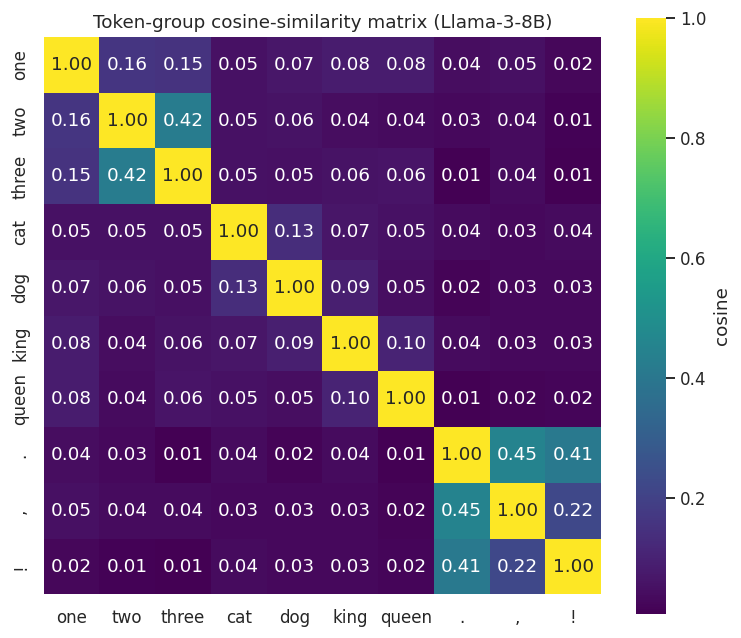

In [10]:
# Similarity heatmap for a small, mixed group of tokens (Llama-3 as reference).
GROUP = ["one", "two", "three", "cat", "dog", "king", "queen", ".", ",", "!"]
key = "Llama-3-8B"
entry = MODELS[key]
ids, labels = [], []
for w in GROUP:
    tid = single_token_id(entry["tok"], w)
    if tid is not None:
        ids.append(tid); labels.append(w)
sub = entry["unit"][ids]
sim = sub @ sub.T                       # cosine similarity matrix for the group
plt.figure(figsize=(7, 6))
sns.heatmap(sim, xticklabels=labels, yticklabels=labels, cmap="viridis",
            annot=True, fmt=".2f", square=True, cbar_kws={"label": "cosine"})
plt.title(f"Token-group cosine-similarity matrix ({key})")
savefig("03_similarity_heatmap.png")

## 4. Dimensionality reduction (PCA / UMAP / t-SNE)

Project a random subset of embeddings to 2-D, coloured by token category, to
see whether categories occupy distinct regions. PCA also gives the explained-
variance spectrum used later for effective-rank / anisotropy.

Llama-3-8B: PC1 explains 0.8% | top-10 PCs explain 3.0%
SinLlama: PC1 explains 0.7% | top-10 PCs explain 2.9%


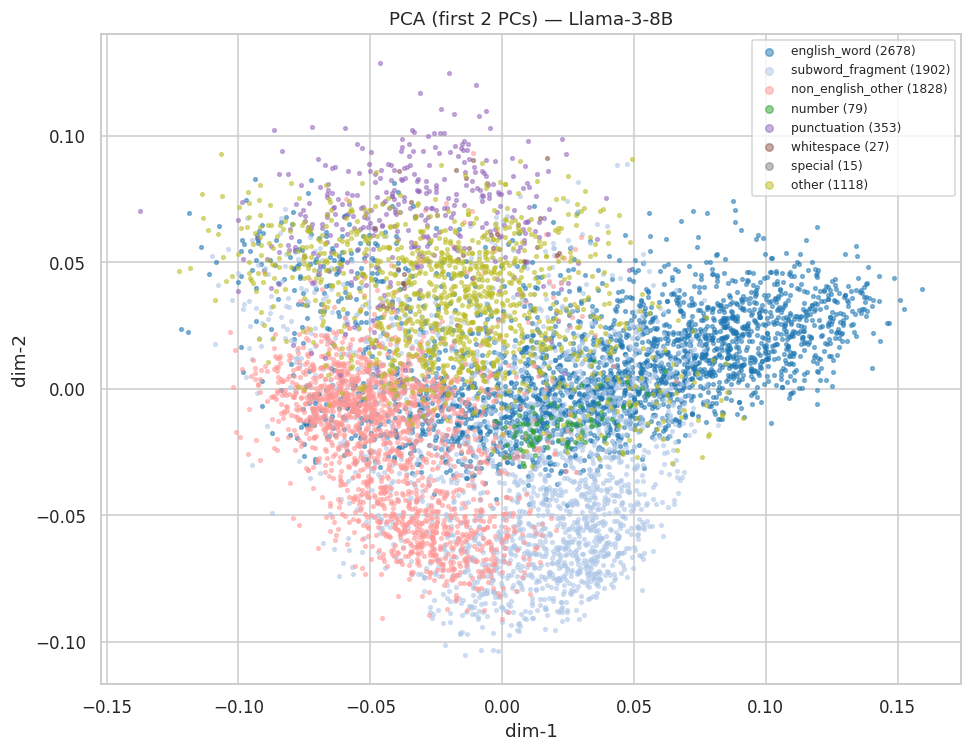

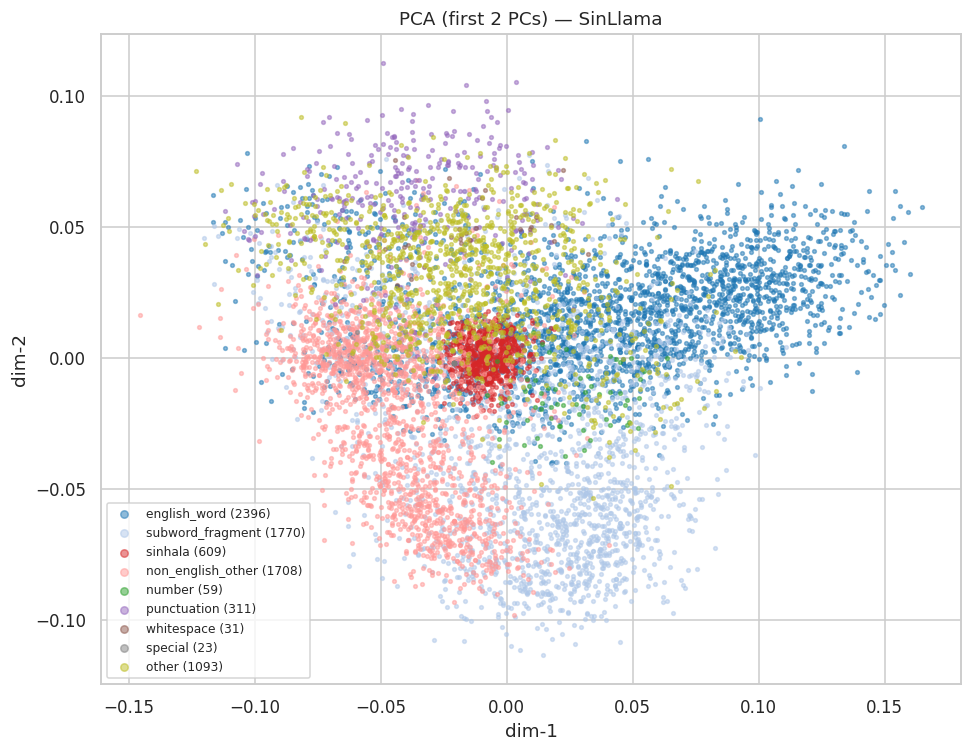

In [11]:
def sample_indices(entry, n):
    "Random subset of token ids for the expensive projections."
    v = entry["emb"].shape[0]
    return rng.choice(v, size=min(n, v), replace=False)

def scatter_by_category(coords, cats, title, fname):
    "2-D scatter coloured by token category."
    plt.figure(figsize=(9, 7))
    for c in [x for x in CAT_COLORS if x in set(cats)]:
        m = cats == c
        plt.scatter(coords[m, 0], coords[m, 1], s=6, alpha=0.5,
                    c=CAT_COLORS[c], label=f"{c} ({m.sum()})")
    plt.legend(markerscale=2, fontsize=8, loc="best")
    plt.title(title); plt.xlabel("dim-1"); plt.ylabel("dim-2")
    savefig(fname)

# Fit a FULL-vocab PCA per model (for explained variance) and reuse for scatter.
for key, entry in MODELS.items():
    pca = PCA(n_components=50, svd_solver="randomized", random_state=SEED)
    pca.fit(entry["emb"])
    entry["pca"] = pca
    SUMMARY[key]["pc1_var_ratio"] = float(pca.explained_variance_ratio_[0])
    SUMMARY[key]["var_top10"] = float(pca.explained_variance_ratio_[:10].sum())
    print(f"{key}: PC1 explains {pca.explained_variance_ratio_[0]*100:.1f}% | "
          f"top-10 PCs explain {pca.explained_variance_ratio_[:10].sum()*100:.1f}%")

# 2-D PCA scatter on a subset, coloured by category.
for key, entry in MODELS.items():
    idx = sample_indices(entry, SUBSET_SIZE)
    entry["subset_idx"] = idx                      # reuse for UMAP/KMeans
    coords = entry["pca"].transform(entry["emb"][idx])[:, :2]
    scatter_by_category(coords, entry["cats"][idx],
                        f"PCA (first 2 PCs) — {key}", f"04_pca_{key}.png")

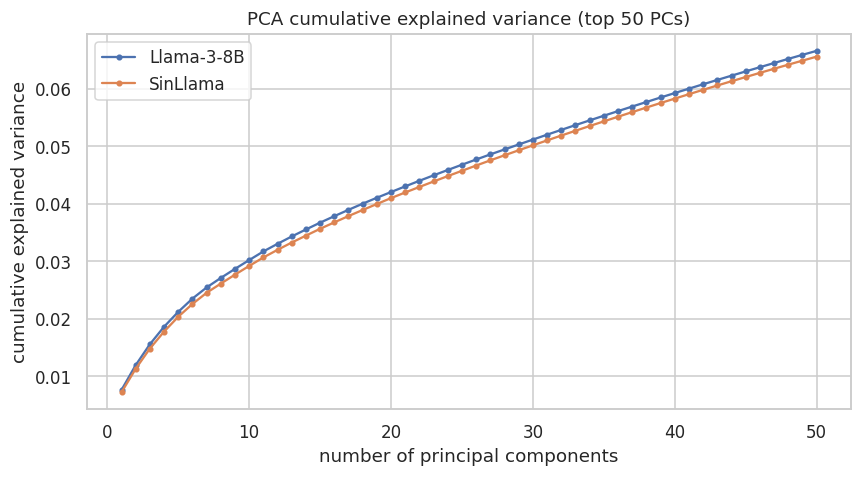

In [12]:
# Explained-variance curves for both models on one axis.
plt.figure(figsize=(8, 4.5))
for key, entry in MODELS.items():
    ev = entry["pca"].explained_variance_ratio_
    plt.plot(np.arange(1, len(ev) + 1), np.cumsum(ev), marker="o", ms=3, label=key)
plt.xlabel("number of principal components")
plt.ylabel("cumulative explained variance")
plt.title("PCA cumulative explained variance (top 50 PCs)")
plt.legend()
savefig("04_pca_cumvar.png")

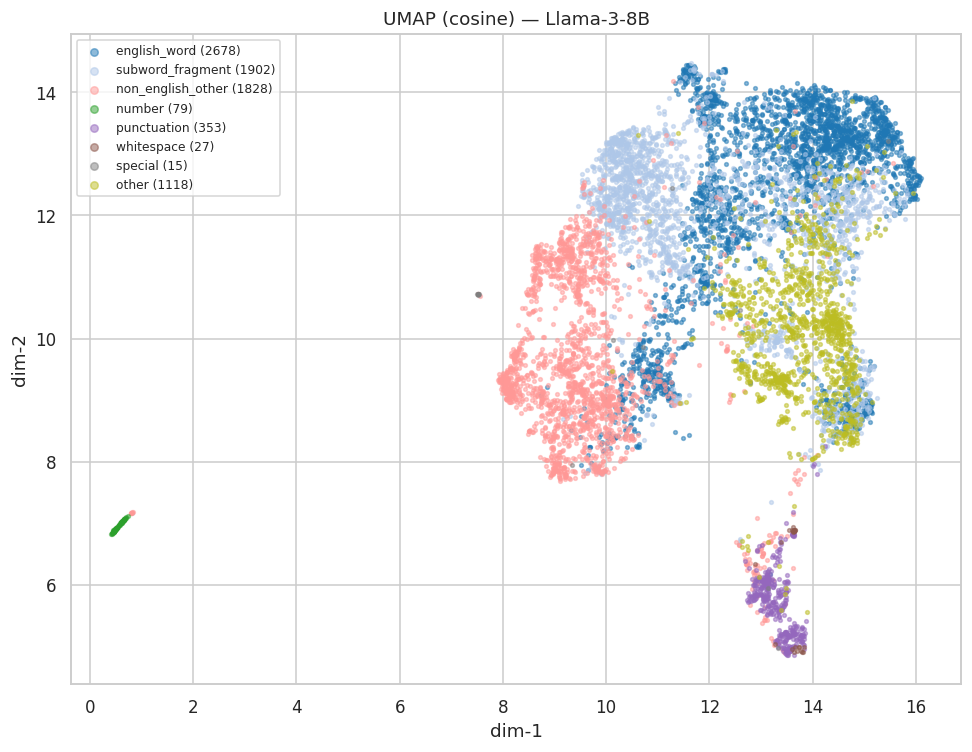

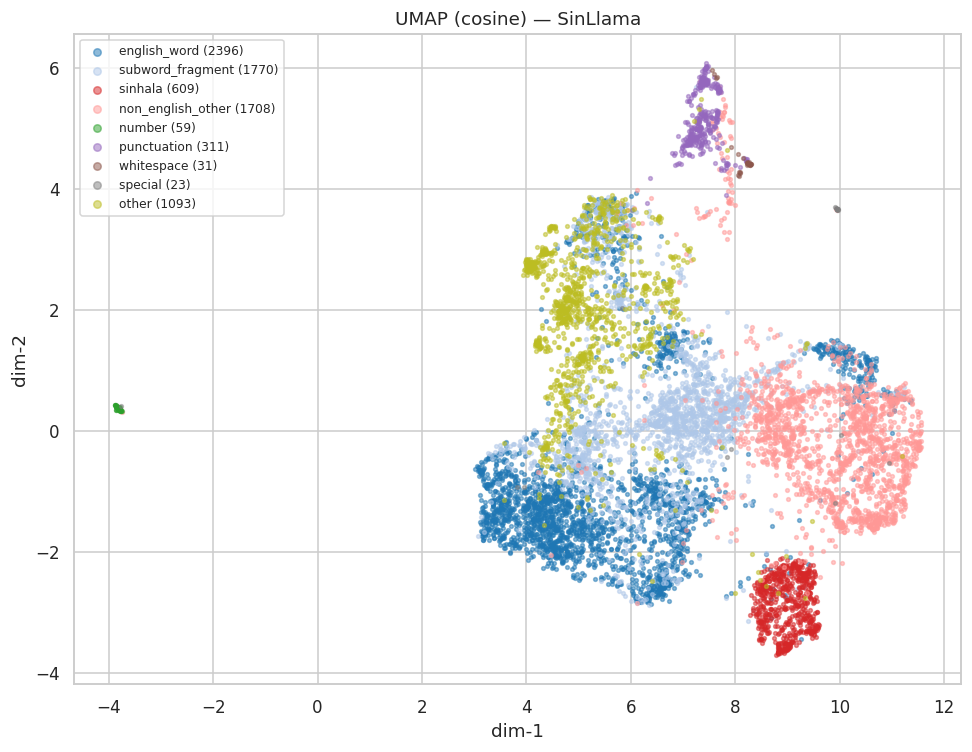

In [13]:
# UMAP on the same subset (non-linear manifold view).
for key, entry in MODELS.items():
    idx = entry["subset_idx"]
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine",
                        random_state=SEED)
    coords = reducer.fit_transform(entry["emb"][idx])
    scatter_by_category(coords, entry["cats"][idx],
                        f"UMAP (cosine) — {key}", f"04_umap_{key}.png")

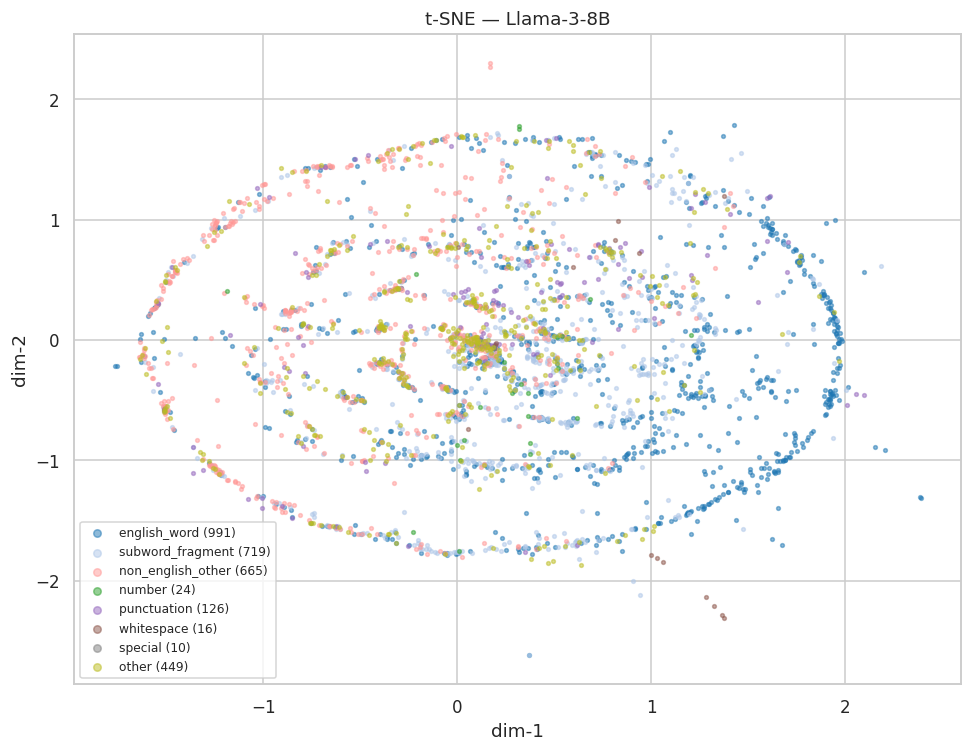

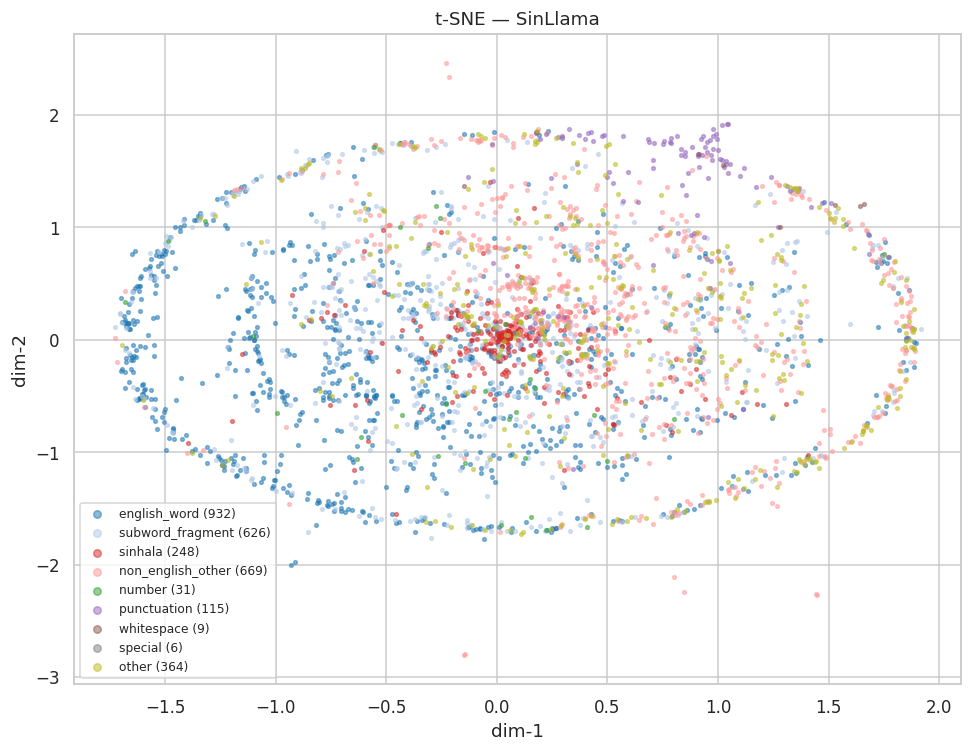

In [14]:
# t-SNE on a smaller subset (quadratic cost). Perplexity 30 is a good default.
for key, entry in MODELS.items():
    idx = sample_indices(entry, TSNE_SIZE)
    coords = TSNE(n_components=2, perplexity=30, init="pca",
                  learning_rate="auto", random_state=SEED).fit_transform(
                      entry["emb"][idx])
    scatter_by_category(coords, entry["cats"][idx],
                        f"t-SNE — {key}", f"04_tsne_{key}.png")

## 5. Clustering

K-Means (k=12) and Ward hierarchical clustering on subsets. We cross-tabulate
clusters against token categories to see whether clusters correspond to
numbers, punctuation, whitespace, language groups or sub-word pieces.

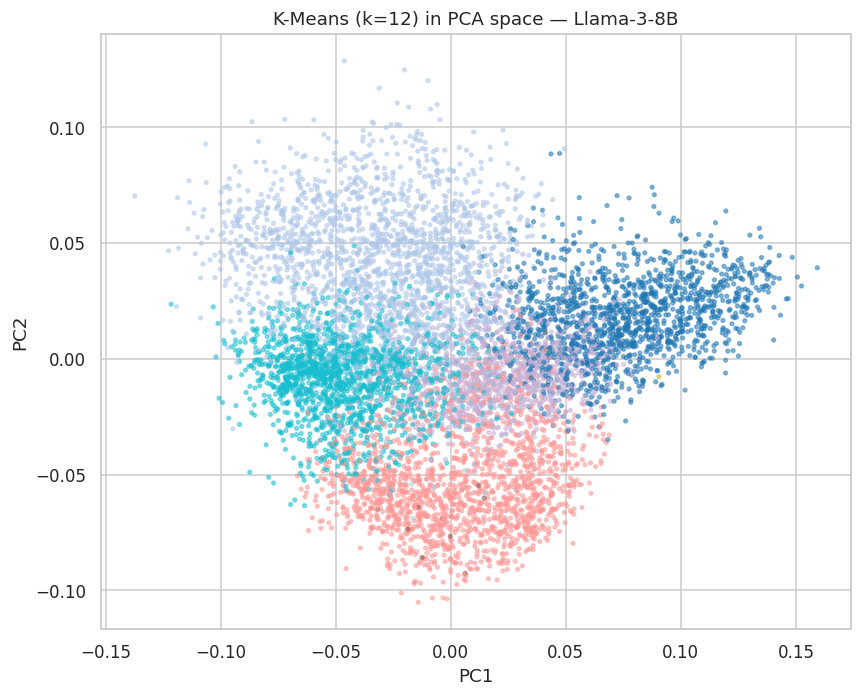


=== Llama-3-8B: cluster x category (rows=cluster) ===


col_0,english_word,non_english_other,number,other,punctuation,special,subword_fragment,whitespace
row_0,,,,,,,,
0,1177,8,1,101,2,0,218,0
1,219,58,0,976,347,0,324,27
2,1,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0
4,0,490,0,11,1,0,1198,0
5,891,16,78,20,0,0,114,0
6,0,5,0,0,0,0,5,0
7,1,0,0,0,0,0,0,0
8,1,0,0,0,0,0,0,0


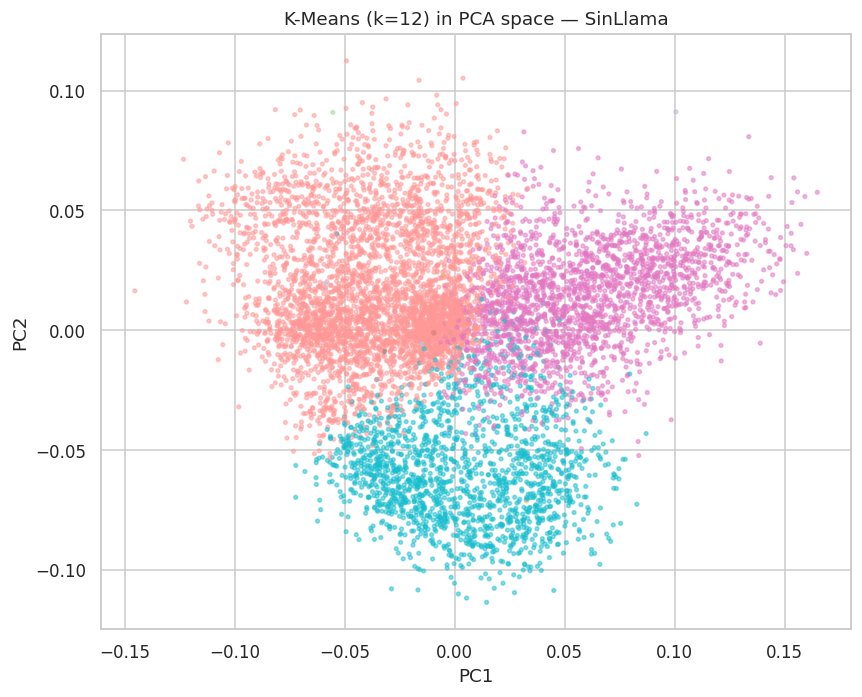


=== SinLlama: cluster x category (rows=cluster) ===


col_0,english_word,non_english_other,number,other,punctuation,sinhala,special,subword_fragment,whitespace
row_0,,,,,,,,,
0,0,0,0,1,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,1,0
3,0,0,0,0,1,0,0,0,0
4,662,1140,3,925,306,602,23,356,30
5,1,0,0,0,0,0,0,0,0
6,1,0,0,0,0,0,0,0,0
7,1724,9,45,138,3,3,0,288,1
8,1,0,0,0,0,0,0,0,0


In [15]:
# K-Means on the projection subset; visualise in PCA space & cross-tab vs category.
K = 12
for key, entry in MODELS.items():
    idx = entry["subset_idx"]
    X = entry["emb"][idx]
    km = KMeans(n_clusters=K, n_init=10, random_state=SEED).fit(X)
    coords = entry["pca"].transform(X)[:, :2]
    plt.figure(figsize=(8, 6.5))
    plt.scatter(coords[:, 0], coords[:, 1], s=6, alpha=0.5,
                c=km.labels_, cmap="tab20")
    plt.title(f"K-Means (k={K}) in PCA space — {key}")
    plt.xlabel("PC1"); plt.ylabel("PC2")
    savefig(f"05_kmeans_{key}.png")

    # Cross-tab: which categories dominate each cluster?
    ct = pd.crosstab(km.labels_, entry["cats"][idx])
    print(f"\n=== {key}: cluster x category (rows=cluster) ===")
    display(ct)

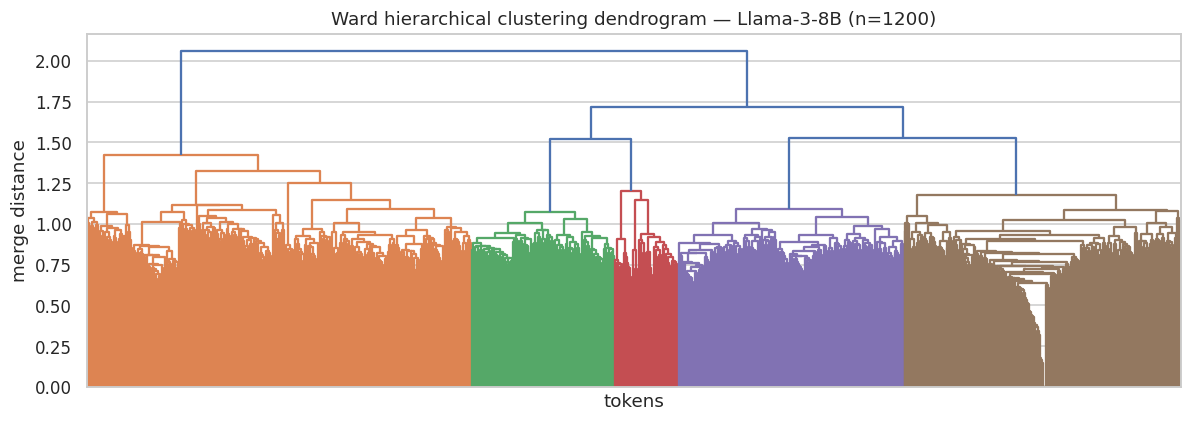

In [16]:
# Ward hierarchical clustering on a small subset -> dendrogram (Llama-3 shown).
key = "Llama-3-8B"
entry = MODELS[key]
idx = sample_indices(entry, HIER_SIZE)
Z = linkage(entry["emb"][idx], method="ward")
plt.figure(figsize=(11, 4))
dendrogram(Z, no_labels=True, color_threshold=None)
plt.title(f"Ward hierarchical clustering dendrogram — {key} (n={len(idx)})")
plt.xlabel("tokens"); plt.ylabel("merge distance")
savefig("05_dendrogram.png")

## 6. Spectral analysis (SVD / covariance spectrum)

Centre the matrix, compute the covariance eigen-spectrum (equivalent to the
squared singular values of the centred matrix), and derive the **effective
rank** two ways: entropy-based ( exp(H) ) and the participation ratio. A low
effective rank relative to 4096 means the representations live in a much
smaller subspace.

Llama-3-8B: effective rank (exp-H)=3543.6 | participation ratio=2449.7 | dims=4096
SinLlama: effective rank (exp-H)=3569.4 | participation ratio=2521.9 | dims=4096


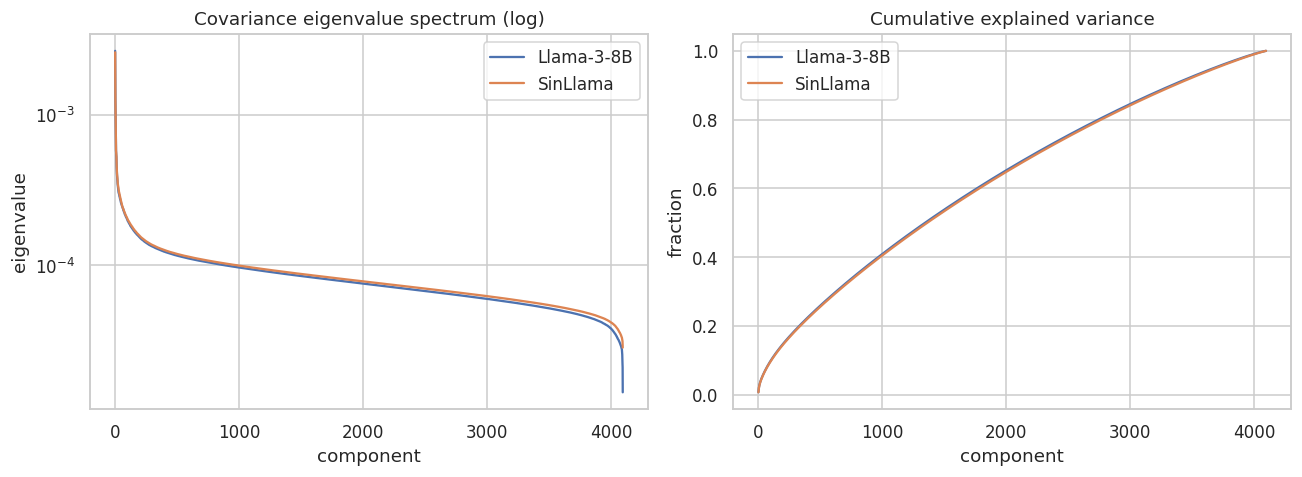

In [17]:
def spectrum_metrics(emb):
    "Return covariance eigenvalues (desc) + effective-rank measures."
    Xc = emb - emb.mean(axis=0, keepdims=True)          # centre
    cov = (Xc.T @ Xc) / (Xc.shape[0] - 1)               # [hidden, hidden]
    eig = np.linalg.eigvalsh(cov)[::-1]                 # descending eigenvalues
    eig = np.clip(eig, 0, None)
    p = eig / eig.sum()
    H = -np.sum(p[p > 0] * np.log(p[p > 0]))            # spectral entropy
    eff_rank_entropy = float(np.exp(H))                 # exp(entropy)
    part_ratio = float((eig.sum() ** 2) / np.sum(eig ** 2))  # participation ratio
    return eig, eff_rank_entropy, part_ratio

plt.figure(figsize=(12, 4.5))
for i, (key, entry) in enumerate(MODELS.items()):
    eig, er, pr = spectrum_metrics(entry["emb"])
    entry["eig"] = eig
    SUMMARY[key]["eff_rank_entropy"] = er
    SUMMARY[key]["participation_ratio"] = pr
    print(f"{key}: effective rank (exp-H)={er:.1f} | "
          f"participation ratio={pr:.1f} | dims={entry['emb'].shape[1]}")
    plt.subplot(1, 2, 1)
    plt.semilogy(eig, label=key)                        # singular/eigen spectrum
    plt.subplot(1, 2, 2)
    plt.plot(np.cumsum(eig) / eig.sum(), label=key)     # cumulative variance
plt.subplot(1, 2, 1); plt.title("Covariance eigenvalue spectrum (log)")
plt.xlabel("component"); plt.ylabel("eigenvalue"); plt.legend()
plt.subplot(1, 2, 2); plt.title("Cumulative explained variance")
plt.xlabel("component"); plt.ylabel("fraction"); plt.legend()
savefig("06_spectrum.png")

## 7. Anisotropy analysis

An embedding space is **anisotropic** if vectors share a dominant common
direction — measured by high average cosine similarity to the mean vector, or
by a large PC1 share. We also compute an isotropy score (Mu et al. 2018):
`I = min_c Z(c) / max_c Z(c)` over principal-axis directions, where
`Z(c) = sum_i exp(c . e_i)`. `I → 1` is isotropic, `I → 0` anisotropic.

Llama-3-8B: mean cos-to-mean = +0.136 (|mean vec| = 0.081) | isotropy I = 0.9724
SinLlama: mean cos-to-mean = +0.134 (|mean vec| = 0.079) | isotropy I = 0.9687


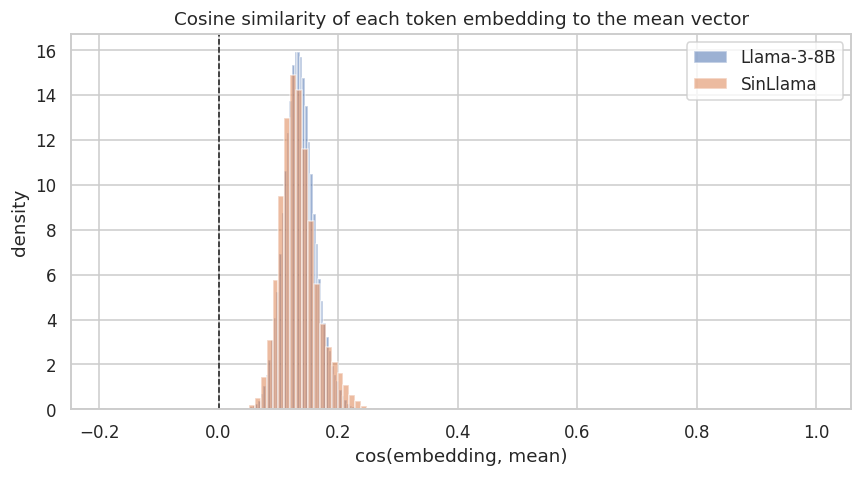

In [18]:
def isotropy_score(emb, pca, n_axes=15, sample=20000):
    "Partition-function isotropy over the top/bottom principal axes."
    idx = rng.choice(emb.shape[0], size=min(sample, emb.shape[0]), replace=False)
    X = emb[idx]
    axes = pca.components_[:n_axes]              # dominant eigenvectors
    Z = np.exp(X @ axes.T).sum(axis=0)           # partition fn per axis
    return float(Z.min() / Z.max())

for key, entry in MODELS.items():
    unit, norms = entry["unit"], entry["norms"]
    mean_vec = entry["emb"].mean(axis=0)
    mean_unit = mean_vec / np.linalg.norm(mean_vec)
    cos_to_mean = unit @ mean_unit               # cosine of every token to mean
    iso = isotropy_score(entry["emb"], entry["pca"])
    SUMMARY[key]["avg_cos_to_mean"] = float(cos_to_mean.mean())
    SUMMARY[key]["isotropy_score"] = iso
    print(f"{key}: mean cos-to-mean = {cos_to_mean.mean():+.3f} "
          f"(|mean vec| = {np.linalg.norm(mean_vec):.3f}) | isotropy I = {iso:.4f}")

# Visualise cosine-to-mean distributions (a right-shifted mass = anisotropy).
plt.figure(figsize=(8, 4.5))
for key, entry in MODELS.items():
    mv = entry["emb"].mean(axis=0); mv /= np.linalg.norm(mv)
    plt.hist(entry["unit"] @ mv, bins=120, alpha=0.55, density=True, label=key)
plt.axvline(0, color="k", lw=1, ls="--")
plt.title("Cosine similarity of each token embedding to the mean vector")
plt.xlabel("cos(embedding, mean)"); plt.ylabel("density"); plt.legend()
savefig("07_anisotropy.png")

## 8. Embedding-norm analysis

Norm histogram broken down by token category, and the tokens with the largest
/ smallest norms. Norm often correlates with token frequency / informativeness.

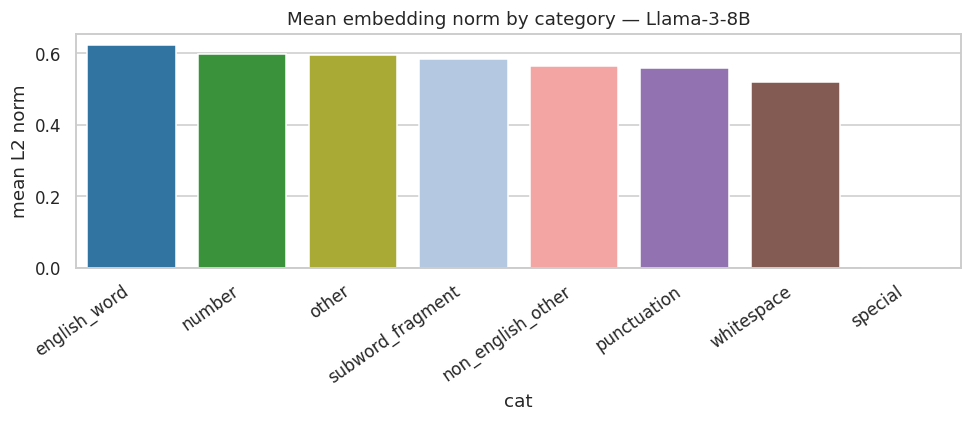


Llama-3-8B largest-norm tokens: [("'innitus'", 0.86), ("'喔'", 0.82), ("' Mandela'", 0.8), ("' Roths'", 0.78), ("' interpersonal'", 0.77), ("' contagious'", 0.77), ("' resentment'", 0.77), ("' stressful'", 0.77), ("' morality'", 0.77), ("' devastating'", 0.77)]
Llama-3-8B smallest-norm tokens: [("'<|reserved_special_token_104|>'", 0.0), ("'<|reserved_special_token_21|>'", 0.0), ("'<|reserved_special_token_217|>'", 0.0), ("'$PostalCodesNL'", 0.0), ("'<|reserved_special_token_210|>'", 0.0), ("'<|reserved_special_token_172|>'", 0.0), ("'<|reserved_special_token_201|>'", 0.0), ("'<|reserved_special_token_158|>'", 0.0), ("'�'", 0.0), ("'<|reserved_special_token_141|>'", 0.0)]


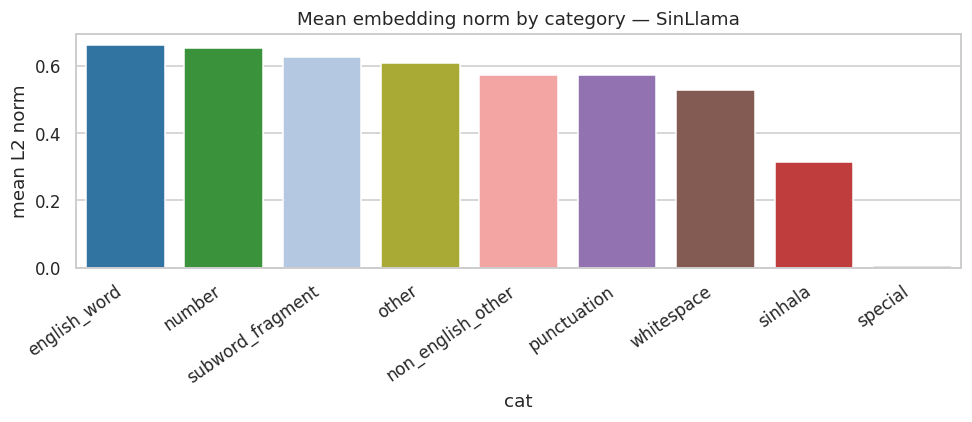


SinLlama largest-norm tokens: [("'innitus'", 0.89), ("' Mandela'", 0.85), ("' Roths'", 0.84), ("'喔'", 0.82), ("' blackmail'", 0.81), ("' erotic'", 0.81), ("' Mourinho'", 0.81), ("' proactive'", 0.81), ("' Omaha'", 0.81), ("' handsome'", 0.81)]
SinLlama smallest-norm tokens: [("'<|reserved_special_token_104|>'", 0.0), ("'<|reserved_special_token_21|>'", 0.0), ("'<|reserved_special_token_217|>'", 0.0), ("'$PostalCodesNL'", 0.0), ("'<|reserved_special_token_210|>'", 0.0), ("'<|reserved_special_token_201|>'", 0.0), ("'<|reserved_special_token_172|>'", 0.0), ("'<|reserved_special_token_158|>'", 0.0), ("'�'", 0.0), ("'<|reserved_special_token_141|>'", 0.0)]


In [19]:
# Mean norm per category (bar) + largest/smallest-norm tokens.
for key, entry in MODELS.items():
    df = pd.DataFrame({"cat": entry["cats"], "norm": entry["norms"]})
    order = df.groupby("cat")["norm"].mean().sort_values(ascending=False)
    plt.figure(figsize=(9, 4))
    sns.barplot(x=order.index, y=order.values,
                palette=[CAT_COLORS.get(c, "#333") for c in order.index])
    plt.xticks(rotation=35, ha="right")
    plt.ylabel("mean L2 norm"); plt.title(f"Mean embedding norm by category — {key}")
    savefig(f"08_norm_by_category_{key}.png")

    n = entry["norms"]
    big = np.argsort(-n)[:10]; small = np.argsort(n)[:10]
    print(f"\n{key} largest-norm tokens:",
          [(repr(entry['readable'][i]), round(float(n[i]), 2)) for i in big])
    print(f"{key} smallest-norm tokens:",
          [(repr(entry['readable'][i]), round(float(n[i]), 2)) for i in small])

## 9. Token-category analysis

For each category: average norm, average **intra-category** cosine similarity
(how tight the cluster is), and token count. For SinLlama this quantifies how
the new Sinhala embeddings compare to the original English vocabulary.

In [20]:
def category_report(entry, max_per_cat=2000):
    "Per-category count, mean norm and mean pairwise cosine (on a capped sample)."
    rows = []
    for c in sorted(set(entry["cats"])):
        ids = np.where(entry["cats"] == c)[0]
        if len(ids) > max_per_cat:                      # cap for the O(n^2) cosine
            ids = rng.choice(ids, size=max_per_cat, replace=False)
        u = entry["unit"][ids]
        sims = u @ u.T
        iu = np.triu_indices(len(ids), k=1)             # off-diagonal only
        mean_cos = float(sims[iu].mean()) if len(iu[0]) else float("nan")
        rows.append({"category": c, "count": int((entry["cats"] == c).sum()),
                     "mean_norm": float(entry["norms"][entry["cats"] == c].mean()),
                     "mean_intra_cos": mean_cos})
    return pd.DataFrame(rows).set_index("category")

for key, entry in MODELS.items():
    print(f"\n=== {key} category report ===")
    display(category_report(entry).round(4))


=== Llama-3-8B category report ===


,count,mean_norm,mean_intra_cos
category,,,
english_word,43044,0.6239,0.0282
non_english_other,30054,0.5659,0.0243
number,1110,0.5985,0.1332
other,18316,0.5953,0.0290
punctuation,5516,0.5585,0.0619
special,256,0.0025,-0.0001
subword_fragment,29430,0.5852,0.0269
whitespace,530,0.5199,0.1322



=== SinLlama category report ===


,count,mean_norm,mean_intra_cos
category,,,
english_word,43044,0.6627,0.0240
non_english_other,30054,0.5737,0.0234
number,1110,0.6533,0.1147
other,18316,0.6096,0.0279
punctuation,5516,0.5732,0.0602
sinhala,11080,0.3152,0.0415
special,256,0.0030,-0.0001
subword_fragment,29430,0.6277,0.0243
whitespace,530,0.5275,0.1284


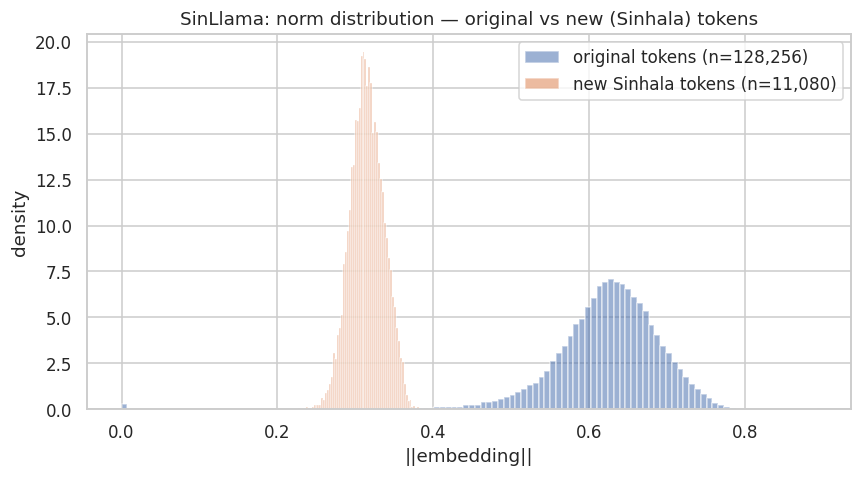

original-token mean norm = 0.620
new-token     mean norm = 0.315


In [21]:
# SinLlama-specific: original vs newly-added (Sinhala) token embeddings.
if MODELS["SinLlama"]["is_new"].any():
    entry = MODELS["SinLlama"]
    is_new = entry["is_new"]
    old_norm, new_norm = entry["norms"][~is_new], entry["norms"][is_new]
    plt.figure(figsize=(8, 4.5))
    plt.hist(old_norm, bins=120, alpha=0.55, density=True,
             label=f"original tokens (n={(~is_new).sum():,})")
    plt.hist(new_norm, bins=120, alpha=0.55, density=True,
             label=f"new Sinhala tokens (n={is_new.sum():,})")
    plt.title("SinLlama: norm distribution — original vs new (Sinhala) tokens")
    plt.xlabel("||embedding||"); plt.ylabel("density"); plt.legend()
    savefig("09_sinllama_old_vs_new_norm.png")
    print(f"original-token mean norm = {old_norm.mean():.3f}")
    print(f"new-token     mean norm = {new_norm.mean():.3f}")

## 10. Neighbourhood analysis

Top-10 nearest neighbours for a set of probe tokens, inspecting semantic vs
morphological vs tokeniser-driven relationships. For SinLlama we additionally
probe a few Sinhala tokens.

In [22]:
PROBE_WORDS = ["cat", "dog", "computer", "run", "happy", "3", "."]
for key, entry in MODELS.items():
    print(f"\n################  {key}  ################")
    for w in PROBE_WORDS:
        tid = single_token_id(entry["tok"], w)
        if tid is None:
            print(f"[{w!r}] not a single token"); continue
        nn = nearest_neighbors(entry, tid, k=10)
        print(f"[{w!r:>10}] -> " + ", ".join(f"{r!r}({s:.2f})" for _, r, s in nn))


################  Llama-3-8B  ################
[     'cat'] -> 'Cat'(0.42), 'CAT'(0.42), ' cat'(0.42), 'cats'(0.36), ' Cat'(0.34), '-cat'(0.31), ' CAT'(0.27), '\tcat'(0.25), '(cat'(0.23), ' cats'(0.23)
[     'dog'] -> 'DOG'(0.42), 'Dog'(0.41), 'dogs'(0.38), ' dog'(0.36), ' Dog'(0.34), ' watchdog'(0.24), ' dogs'(0.22), 'og'(0.19), ' Dogs'(0.18), 'Cat'(0.14)
['computer'] -> ' computer'(0.46), 'Computer'(0.42), ' Computer'(0.39), ' computers'(0.35), 'comput'(0.30), 'puter'(0.27), ' COMPUTER'(0.27), ' Computers'(0.21), '퓨터'(0.19), ' computing'(0.18)
[     'run'] -> 'Run'(0.46), 'RUN'(0.43), ' run'(0.43), ' Run'(0.37), 'runs'(0.35), '-run'(0.33), ' RUN'(0.31), '\trun'(0.29), ' runs'(0.28), '_run'(0.26)
[   'happy'] -> ' happy'(0.40), ' Happy'(0.35), 'Happy'(0.35), ' unhappy'(0.31), ' happier'(0.18), 'appy'(0.18), ' happiness'(0.17), 'appiness'(0.16), ' lucky'(0.15), ' HAPP'(0.14)
[       '3'] -> '2'(0.63), '4'(0.61), '5'(0.54), '7'(0.49), '6'(0.49), '1'(0.47), '8'(0.42), '9'(0.42), '۳'(0.4

In [23]:
# SinLlama only: nearest neighbours of a few actual Sinhala tokens.
entry = MODELS["SinLlama"]
new_ids = np.where(entry["is_new"])[0]
# Pick Sinhala tokens that decode to multi-character strings (more meaningful).
candidates = [i for i in new_ids if len(entry["readable"][i].strip()) >= 2][:6]
for tid in candidates:
    nn = nearest_neighbors(entry, int(tid), k=8)
    print(f"[{entry['readable'][tid]!r}] -> "
          + ", ".join(f"{r!r}({s:.2f})" for _, r, s in nn))

['න්'] -> 'ං'(0.27), 'න්ගේ'(0.25), ' න්'(0.21), 'ෙන්'(0.21), 'න'(0.21), 'ිරාල්'(0.20), 'ින්'(0.19), '්'(0.19)
['ත්'] -> 'ටත්'(0.25), 'යත්'(0.23), ' ත්'(0.22), 'ීමත්'(0.22), 'වත්'(0.21), ' ගැනීමත්'(0.20), 'ීමටත්'(0.20), ' කිරීමත්'(0.20)
['ිය'] -> 'ියක්'(0.25), 'ීය'(0.22), 'ියට'(0.21), 'ි'(0.19), 'විය'(0.19), 'ය'(0.19), 'ිරාල්'(0.18), 'ියගේ'(0.18)
['ක්'] -> ' ක්'(0.29), 'යක්'(0.28), 'කට'(0.20), 'ක්ද'(0.20), 'ෙක්'(0.20), 'කින්'(0.20), 'ිරාල්'(0.19), 'වක්'(0.19)
['්\u200d'] -> '්'(0.35), '\u200d්'(0.28), 'ර්\u200d'(0.21), 'න්\u200d'(0.20), 'ත්\u200d'(0.19), 'ිරාල්'(0.15), 'ෟ'(0.15), 'ඤ්'(0.15)
['න්න'] -> ' කරන්න'(0.26), 'ෙන්න'(0.23), 'න්නට'(0.21), ' වෙන්න'(0.20), ' දෙන්න'(0.19), ' ඔන්න'(0.19), ' එන්න'(0.19), ' ගන්න'(0.19)


## 11. Frequency-based analysis (optional)

If token-frequency counts are available (e.g. from the CPT corpus) you can
correlate frequency with embedding norm / neighbourhood density. Drop a JSON
file mapping `token_id -> count` at the path below to enable it; otherwise this
cell reports that no data was found and skips gracefully.

In [24]:
FREQ_PATH = "/ml/SinLlama_CPT/weights_analysis/token_freq.json"  # {id: count}
if os.path.exists(FREQ_PATH):
    freq_map = {int(k): v for k, v in json.load(open(FREQ_PATH)).items()}
    for key, entry in MODELS.items():
        v = entry["emb"].shape[0]
        freq = np.array([freq_map.get(i, 0) for i in range(v)], dtype=float)
        mask = freq > 0
        plt.figure(figsize=(7, 5))
        plt.scatter(np.log1p(freq[mask]), entry["norms"][mask], s=4, alpha=0.3)
        plt.xlabel("log(1+frequency)"); plt.ylabel("embedding norm")
        plt.title(f"Frequency vs norm — {key}")
        savefig(f"11_freq_vs_norm_{key}.png")
        corr = np.corrcoef(np.log1p(freq[mask]), entry["norms"][mask])[0, 1]
        print(f"{key}: corr(log-freq, norm) = {corr:.3f}")
else:
    print(f"No frequency file at {FREQ_PATH} -> skipping section 11.")
    print("To enable: save a JSON dict {token_id: count} at that path and re-run.")

No frequency file at /ml/SinLlama_CPT/weights_analysis/token_freq.json -> skipping section 11.
To enable: save a JSON dict {token_id: count} at that path and re-run.


## 12. Distance distribution & hubness

Histogram of pairwise cosine similarities on a random sample (its mean measures
global anisotropy; its spread measures how discriminative the space is), plus a
**hubness** analysis — the k-occurrence distribution counts how often each token
shows up in other tokens' nearest-neighbour lists. A heavy right tail indicates
hub tokens that dominate retrieval.

Llama-3-8B: mean pairwise cos = +0.018, var = 0.0004
   top hubs: [("' evaluation'", 93), ("' points'", 84), ("' presentation'", 76), ("' jednoduch'", 73), ("' center'", 67)]
SinLlama: mean pairwise cos = +0.018, var = 0.0004
   top hubs: [("' levels'", 76), ("' space'", 70), ("' තහන'", 66), ("' position'", 65), ("' channels'", 63)]


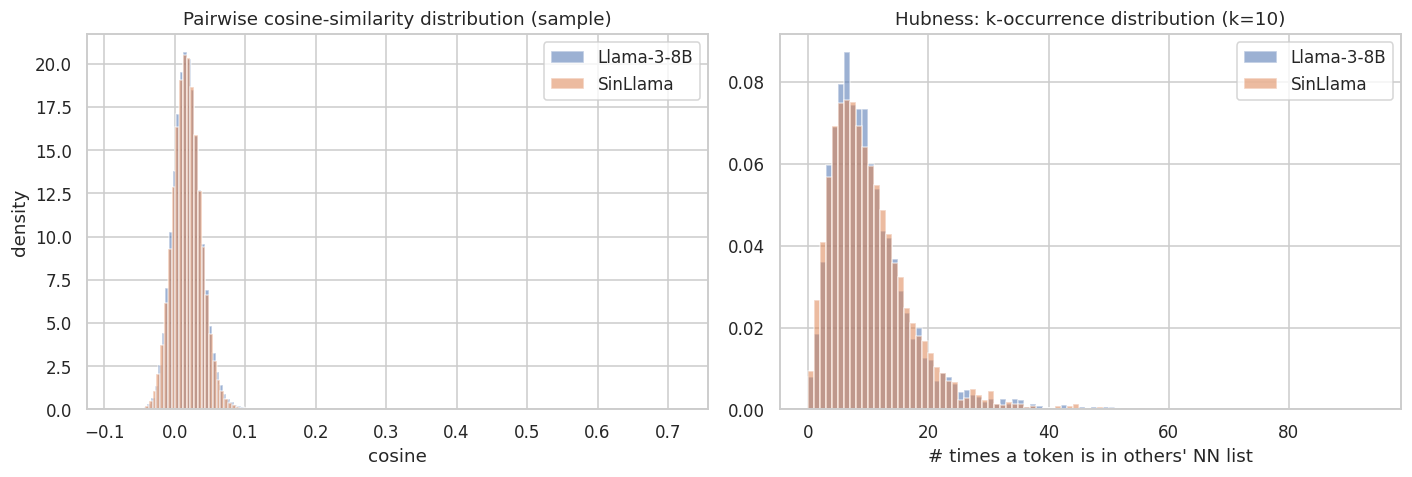

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for key, entry in MODELS.items():
    # --- pairwise cosine similarity on a random sample ---
    idx = sample_indices(entry, PAIRWISE_N)
    u = entry["unit"][idx]
    sims = (u @ u.T)[np.triu_indices(len(idx), k=1)]
    SUMMARY[key]["mean_pairwise_cos"] = float(sims.mean())
    SUMMARY[key]["var_pairwise_cos"]  = float(sims.var())
    ax[0].hist(sims, bins=150, alpha=0.55, density=True, label=key)
    print(f"{key}: mean pairwise cos = {sims.mean():+.3f}, var = {sims.var():.4f}")

    # --- hubness: k-occurrence (how often each token is someone's neighbour) ---
    hidx = sample_indices(entry, HUB_N)
    nn = NearestNeighbors(n_neighbors=11, metric="cosine").fit(entry["unit"][hidx])
    _, neigh = nn.kneighbors(entry["unit"][hidx])
    kocc = np.bincount(neigh[:, 1:].ravel(), minlength=len(hidx))  # exclude self
    ax[1].hist(kocc, bins=range(0, kocc.max() + 2), alpha=0.55,
               density=True, label=key)
    hubs = np.argsort(-kocc)[:5]
    print(f"   top hubs: "
          f"{[(repr(entry['readable'][hidx[h]]), int(kocc[h])) for h in hubs]}")
ax[0].set_title("Pairwise cosine-similarity distribution (sample)")
ax[0].set_xlabel("cosine"); ax[0].set_ylabel("density"); ax[0].legend()
ax[1].set_title("Hubness: k-occurrence distribution (k=10)")
ax[1].set_xlabel("# times a token is in others' NN list"); ax[1].legend()
savefig("12_distance_hubness.png")

## 13. Visualisation index

All figures were saved to `FIG_DIR` as they were produced. The cell below lists
them for convenience.

In [26]:
print("Figures written to", FIG_DIR, ":")
for f in sorted(os.listdir(FIG_DIR)):
    print("  -", f)

Figures written to /ml/SinLlama_CPT/weights_analysis/figures :
  - 02_basic_distributions.png
  - 03_similarity_heatmap.png
  - 04_pca_Llama-3-8B.png
  - 04_pca_SinLlama.png
  - 04_pca_cumvar.png
  - 04_tsne_Llama-3-8B.png
  - 04_tsne_SinLlama.png
  - 04_umap_Llama-3-8B.png
  - 04_umap_SinLlama.png
  - 05_dendrogram.png
  - 05_kmeans_Llama-3-8B.png
  - 05_kmeans_SinLlama.png
  - 06_spectrum.png
  - 07_anisotropy.png
  - 08_norm_by_category_Llama-3-8B.png
  - 08_norm_by_category_SinLlama.png
  - 09_sinllama_old_vs_new_norm.png
  - 12_distance_hubness.png


## 14. Research questions — summary table

The scalar metrics collected during the run are assembled into one comparison
table, followed by programmatic answers to the questions in `todo.txt`.

In [27]:
summary_df = pd.DataFrame(SUMMARY).T
display(summary_df.round(4))

d = SUMMARY
def cmp(metric, fmt="{:.3f}"):
    return " | ".join(f"{k}: {fmt.format(d[k][metric])}" for k in d)

print("\n================ ANSWERS ================")
print(f"1. Is the space anisotropic? mean cos-to-mean -> {cmp('avg_cos_to_mean')}")
print(f"   isotropy score I (1=isotropic) -> {cmp('isotropy_score','{:.4f}')}")
print(f"   => values well above 0 / I well below 1 indicate anisotropy.")
print(f"2. Uniformly distributed? mean pairwise cosine -> {cmp('mean_pairwise_cos')}")
print(f"   (near 0 = closer to uniform on the sphere).")
print(f"3. Do similar tokens cluster? -> see PCA/UMAP/t-SNE scatters & KMeans "
      f"cross-tabs (category-coherent clusters).")
print(f"4. Punctuation / numbers separate regions? -> inspect cluster x category "
      f"cross-tabs in section 5 and the category scatters in section 4/9.")
print(f"5. Hub tokens? -> yes/no per the k-occurrence tail in section 12.")
print(f"6. Variance in first few PCs: PC1 -> {cmp('pc1_var_ratio')}; "
      f"top-10 -> {cmp('var_top10')}")
print(f"7. Intrinsic dimensionality: effective rank (exp-H) -> "
      f"{cmp('eff_rank_entropy','{:.1f}')}; participation ratio -> "
      f"{cmp('participation_ratio','{:.1f}')} (out of 4096).")

,pc1_var_ratio,var_top10,eff_rank_entropy,participation_ratio,avg_cos_to_mean,isotropy_score,mean_pairwise_cos,var_pairwise_cos
Llama-3-8B,0.0076,0.0302,3543.5616,2449.6662,0.1356,0.9724,0.0184,0.0004
SinLlama,0.0072,0.0292,3569.4342,2521.8893,0.1343,0.9687,0.0179,0.0004



================ ANSWERS ================
1. Is the space anisotropic? mean cos-to-mean -> Llama-3-8B: 0.136 | SinLlama: 0.134
   isotropy score I (1=isotropic) -> Llama-3-8B: 0.9724 | SinLlama: 0.9687
   => values well above 0 / I well below 1 indicate anisotropy.
2. Uniformly distributed? mean pairwise cosine -> Llama-3-8B: 0.018 | SinLlama: 0.018
   (near 0 = closer to uniform on the sphere).
3. Do similar tokens cluster? -> see PCA/UMAP/t-SNE scatters & KMeans cross-tabs (category-coherent clusters).
4. Punctuation / numbers separate regions? -> inspect cluster x category cross-tabs in section 5 and the category scatters in section 4/9.
5. Hub tokens? -> yes/no per the k-occurrence tail in section 12.
6. Variance in first few PCs: PC1 -> Llama-3-8B: 0.008 | SinLlama: 0.007; top-10 -> Llama-3-8B: 0.030 | SinLlama: 0.029
7. Intrinsic dimensionality: effective rank (exp-H) -> Llama-3-8B: 3543.6 | SinLlama: 3569.4; participation ratio -> Llama-3-8B: 2449.7 | SinLlama: 2521.9 (out of 4

### Interpreting the Llama-3 vs SinLlama comparison

Key things to look for when reading the results above:

* **Effective rank & PC1 share** — did continual pretraining + vocabulary
  extension expand or collapse the intrinsic dimensionality of the embedding
  space?
* **New-token geometry (section 9)** — do the 11,080 new Sinhala embeddings
  have similar norms to the original vocabulary, or were they initialised /
  trained into a different regime? Very small norms or a tight cluster suggest
  under-trained new tokens.
* **Anisotropy (section 7)** — a higher mean cos-to-mean / lower isotropy score
  means a stronger shared "rogue" direction, which is common in LM embeddings
  and affects downstream cosine-similarity quality.
* **Nearest neighbours (section 10)** — for SinLlama, do Sinhala tokens find
  other Sinhala tokens as neighbours (a coherent Sinhala sub-space) or do they
  scatter among English sub-words?